# Notebook 02 — Feature Engineering

**Projet :** Analyse et Modélisation des Trajets des Taxis Jaunes de New York  
**Formation :** L3 DANT   
**Auteur :** Maissa  SACI

---

Ce notebook crée de nouvelles variables à partir des données nettoyées pour enrichir
les modèles des étapes suivantes. Plus les features sont pertinentes, meilleures seront
les performances en régression et en clustering.

**Tickets couverts :**
- **T-05** — Feature Engineering obligatoire
- **T-06** — Features bonus

**Variables créées :**
- *Obligatoires :* `duree_course`, `heure_journee`, `jour_semaine`, `est_weekend`, `est_heure_pointe`
- *Bonus :* `vitesse_moyenne`, `est_trajet_aeroport`, `heure_sin`, `heure_cos`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_parquet('../data/yellow_tripdata_clean.parquet')
print(f'Dataset charge : {df.shape[0]:,} lignes, {df.shape[1]} colonnes')
df.head()

Dataset charge : 64,452 lignes, 20 colonnes


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2026-01-18 12:35:13,2026-01-18 12:46:05,1.0,3.90,1.0,N,68,238,1,17.0,3.25,0.5,2.50,0.0,1.0,24.25,2.5,0.0,0.75
1,2,2026-01-09 10:35:27,2026-01-09 11:05:50,1.0,13.79,1.0,N,13,138,1,55.5,5.00,0.5,19.57,0.0,1.0,84.82,2.5,0.0,0.75
2,2,2026-01-24 22:26:51,2026-01-24 22:37:03,1.0,1.76,1.0,N,164,79,2,11.4,1.00,0.5,0.00,0.0,1.0,17.15,2.5,0.0,0.75
3,2,2026-01-27 09:30:30,2026-01-27 09:44:06,2.0,1.21,1.0,N,141,262,1,12.8,0.00,0.5,3.36,0.0,1.0,20.16,2.5,0.0,0.00
4,2,2026-01-22 21:18:42,2026-01-22 21:32:22,1.0,2.98,1.0,N,229,238,1,15.6,1.00,0.5,2.50,0.0,1.0,23.85,2.5,0.0,0.75


## 2.1 Variables temporelles obligatoires

On extrait toutes les composantes temporelles à partir de `tpep_pickup_datetime`
(date/heure de prise en charge) et on calcule la durée du trajet depuis les deux horodatages.

### `duree_course` — Durée du trajet en minutes

Calculée comme la différence entre `tpep_dropoff_datetime` et `tpep_pickup_datetime`.
On s'assure que le résultat est positif (les durées négatives ont été supprimées dans le notebook 01).

In [2]:
df['duree_course'] = (
    pd.to_datetime(df['tpep_dropoff_datetime']) -
    pd.to_datetime(df['tpep_pickup_datetime'])
).dt.total_seconds() / 60

print(f'duree_course — min : {df["duree_course"].min():.1f} min')
print(f'duree_course — max : {df["duree_course"].max():.1f} min')
print(f'duree_course — med : {df["duree_course"].median():.1f} min')

duree_course — min : 0.1 min
duree_course — max : 173.2 min
duree_course — med : 11.8 min


### `heure_journee`, `jour_semaine`, `est_weekend`, `est_heure_pointe`

- `heure_journee` : heure de la prise en charge (0 à 23)
- `jour_semaine` : jour de la semaine (0 = lundi, 6 = dimanche)
- `est_weekend` : 1 si samedi ou dimanche, 0 sinon
- `est_heure_pointe` : 1 si la course se situe pendant les heures de rush (7h-9h ou 17h-19h),
  identifiées dans l'EDA (notebook 01)

In [3]:
df['heure_journee']    = pd.to_datetime(df['tpep_pickup_datetime']).dt.hour
df['jour_semaine']     = pd.to_datetime(df['tpep_pickup_datetime']).dt.dayofweek
df['est_weekend']      = (df['jour_semaine'] >= 5).astype(int)
df['est_heure_pointe'] = df['heure_journee'].isin([7, 8, 9, 17, 18, 19]).astype(int)

print('Repartition est_weekend      :', df['est_weekend'].value_counts().to_dict())
print('Repartition est_heure_pointe :', df['est_heure_pointe'].value_counts().to_dict())

Repartition est_weekend      : {0: 47399, 1: 17053}
Repartition est_heure_pointe : {0: 44336, 1: 20116}


## 2.2 Variables bonus

Ces variables enrichissent le dataset avec des informations dérivées pertinentes
pour améliorer les performances des modèles.

### `vitesse_moyenne` — Vitesse en miles/heure

Calculée comme `trip_distance / (duree_course / 60)`. On remplace les valeurs
infinies ou aberrantes (vitesse > 100 mph) par NaN, car elles correspondraient
à des erreurs résiduelles dans les données.

In [4]:
df['vitesse_moyenne'] = df['trip_distance'] / (df['duree_course'] / 60)
df['vitesse_moyenne'] = df['vitesse_moyenne'].replace([np.inf, -np.inf], np.nan)
df.loc[df['vitesse_moyenne'] > 100, 'vitesse_moyenne'] = np.nan

print(f'vitesse_moyenne — med : {df["vitesse_moyenne"].median():.1f} mph')
print(f'vitesse_moyenne — max : {df["vitesse_moyenne"].max():.1f} mph')
print(f'vitesse_moyenne — NaN : {df["vitesse_moyenne"].isna().sum():,}')

vitesse_moyenne — med : 9.0 mph
vitesse_moyenne — max : 93.6 mph
vitesse_moyenne — NaN : 2


### `est_trajet_aeroport` — Trajet vers JFK ou Newark

Dérivé de `RatecodeID` : valeur 2 = tarif JFK, valeur 3 = tarif Newark.
Ces courses ont un comportement tarifaire spécifique (forfait fixe) qui peut
influencer les modèles de prédiction du montant.

In [18]:
df['est_trajet_aeroport'] = df['RatecodeID'].isin([2, 3]).astype(int)

print('Repartition est_trajet_aeroport :', df['est_trajet_aeroport'].value_counts().to_dict())
print(f'Soit {df["est_trajet_aeroport"].mean()*100:.1f}% des courses vers un aeroport')

Repartition est_trajet_aeroport : {0: 62151, 1: 2301}
Soit 3.6% des courses vers un aeroport


### `heure_sin` / `heure_cos` — Encodage cyclique de l'heure

L'heure est une variable cyclique : 23h et 0h sont proches, mais une représentation
linéaire les traite comme opposées. L'encodage sin/cos préserve cette continuité
temporelle et améliore les performances des modèles linéaires.

In [6]:
df['heure_sin'] = np.sin(2 * np.pi * df['heure_journee'] / 24)
df['heure_cos'] = np.cos(2 * np.pi * df['heure_journee'] / 24)

print('Nouvelles colonnes creees :')
nouvelles_cols = ['duree_course', 'heure_journee', 'jour_semaine', 'est_weekend',
                  'est_heure_pointe', 'vitesse_moyenne', 'est_trajet_aeroport',
                  'heure_sin', 'heure_cos']
print(df[nouvelles_cols].describe().round(2))

Nouvelles colonnes creees :
       duree_course  heure_journee  jour_semaine  est_weekend  \
count      64452.00       64452.00      64452.00     64452.00   
mean          15.17          14.51          3.08         0.26   
std           11.95           5.54          1.82         0.44   
min            0.05           0.00          0.00         0.00   
25%            7.28          11.00          2.00         0.00   
50%           11.83          15.00          3.00         0.00   
75%           19.13          19.00          5.00         1.00   
max          173.15          23.00          6.00         1.00   

       est_heure_pointe  vitesse_moyenne  est_trajet_aeroport  heure_sin  \
count          64452.00         64450.00             64452.00   64452.00   
mean               0.31            10.83                 0.04      -0.34   
std                0.46             6.76                 0.19       0.63   
min                0.00             0.07                 0.00      -1.00   
25%   

## 2.3 Visualisations des nouvelles variables

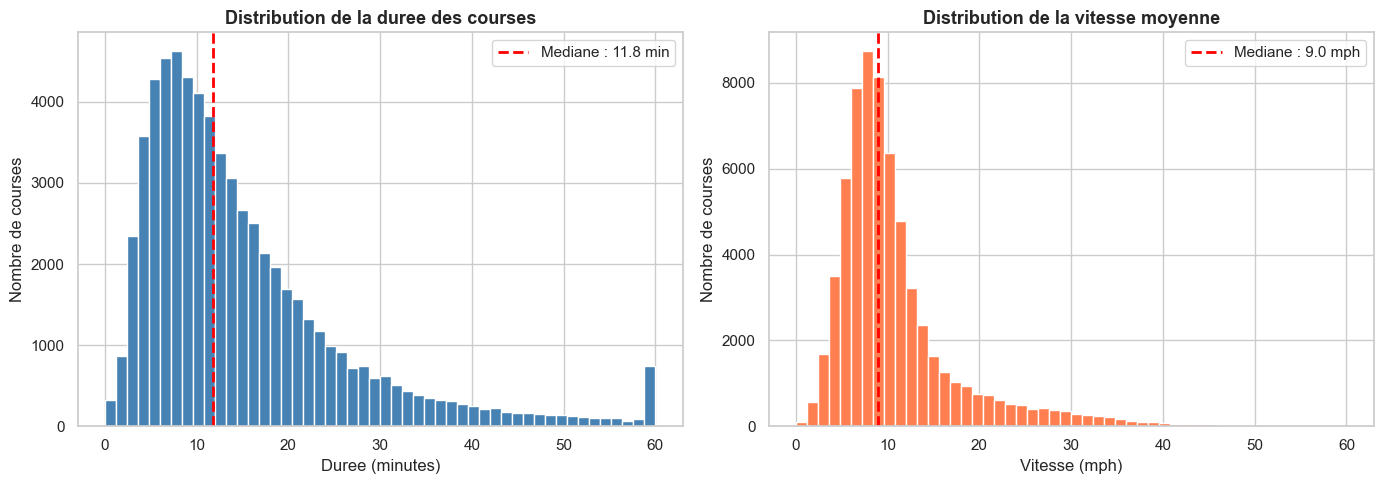

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de la durée des courses
df['duree_course'].clip(0, 60).hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
mediane_duree = df['duree_course'].median()
axes[0].axvline(mediane_duree, color='red', linestyle='--', linewidth=2,
                label=f'Mediane : {mediane_duree:.1f} min')
axes[0].set_title('Distribution de la duree des courses', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Duree (minutes)')
axes[0].set_ylabel('Nombre de courses')
axes[0].legend()

# Distribution de la vitesse moyenne
df['vitesse_moyenne'].dropna().clip(0, 60).hist(bins=50, ax=axes[1], color='coral', edgecolor='white')
mediane_vit = df['vitesse_moyenne'].median()
axes[1].axvline(mediane_vit, color='red', linestyle='--', linewidth=2,
                label=f'Mediane : {mediane_vit:.1f} mph')
axes[1].set_title('Distribution de la vitesse moyenne', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Vitesse (mph)')
axes[1].set_ylabel('Nombre de courses')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/02_duree_vitesse.png', dpi=150)
plt.show()

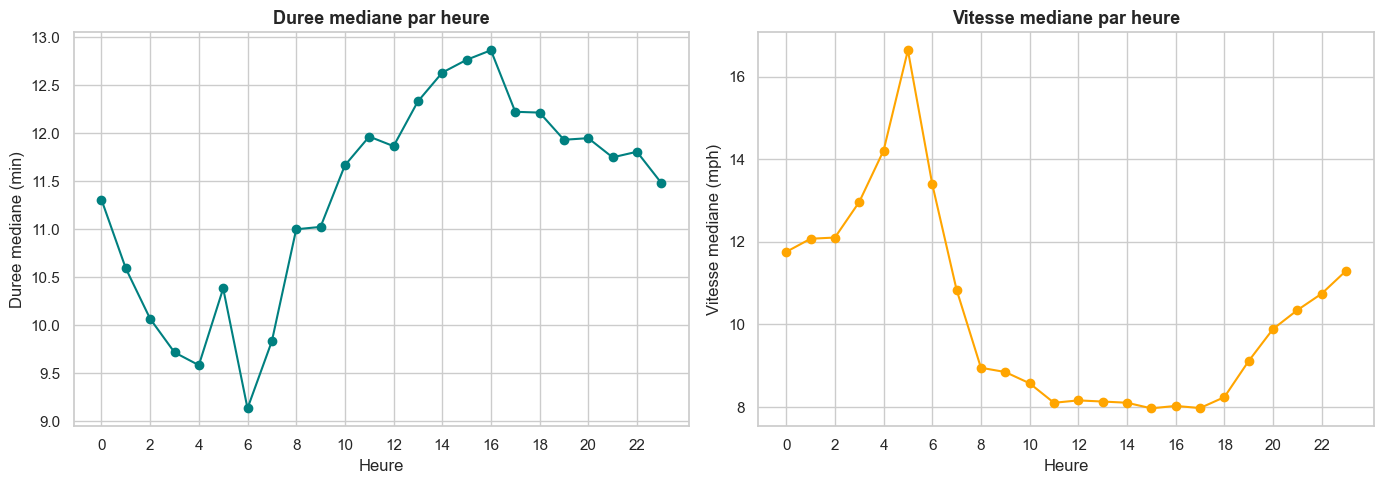

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Durée moyenne par heure de la journée
df.groupby('heure_journee')['duree_course'].median().plot(
    ax=axes[0], marker='o', color='teal')
axes[0].set_title('Duree mediane par heure', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Duree mediane (min)')
axes[0].set_xticks(range(0, 24, 2))

# Vitesse moyenne par heure
df.groupby('heure_journee')['vitesse_moyenne'].median().plot(
    ax=axes[1], marker='o', color='orange')
axes[1].set_title('Vitesse mediane par heure', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('Vitesse mediane (mph)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('../figures/02_temporel.png', dpi=150)
plt.show()

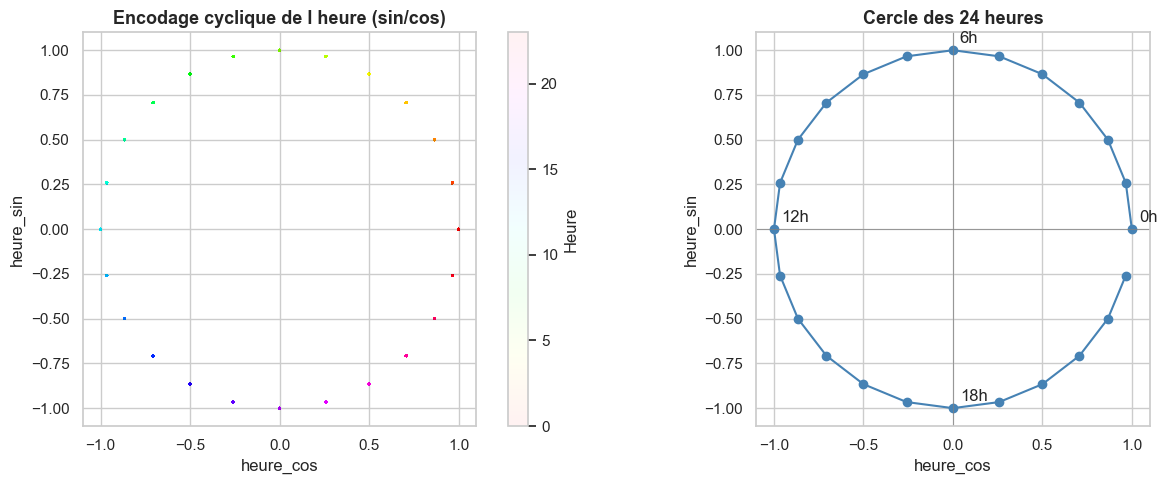

In [10]:
# Encodage cyclique — les 24 heures projetées sur un cercle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter sin/cos coloré par heure
scatter = axes[0].scatter(df['heure_cos'], df['heure_sin'],
                          c=df['heure_journee'], cmap='hsv', alpha=0.05, s=1)
plt.colorbar(scatter, ax=axes[0], label='Heure')
axes[0].set_title('Encodage cyclique de l heure (sin/cos)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('heure_cos')
axes[0].set_ylabel('heure_sin')
axes[0].set_aspect('equal')

# Moyenne des valeurs sin/cos par heure pour vérifier la continuité
heure_moy = df.groupby('heure_journee')[['heure_sin', 'heure_cos']].mean()
axes[1].plot(heure_moy['heure_cos'], heure_moy['heure_sin'], 'o-', color='steelblue')
for h in [0, 6, 12, 18]:
    x = heure_moy.loc[h, 'heure_cos']
    y = heure_moy.loc[h, 'heure_sin']
    axes[1].annotate(f'{h}h', (x, y), textcoords='offset points', xytext=(5, 5))
axes[1].set_title('Cercle des 24 heures', fontsize=13, fontweight='bold')
axes[1].set_xlabel('heure_cos')
axes[1].set_ylabel('heure_sin')
axes[1].set_aspect('equal')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('../figures/02_encodage_cyclique.png', dpi=150)
plt.show()

### Tarifs selon la période : semaine/weekend et heure de pointe

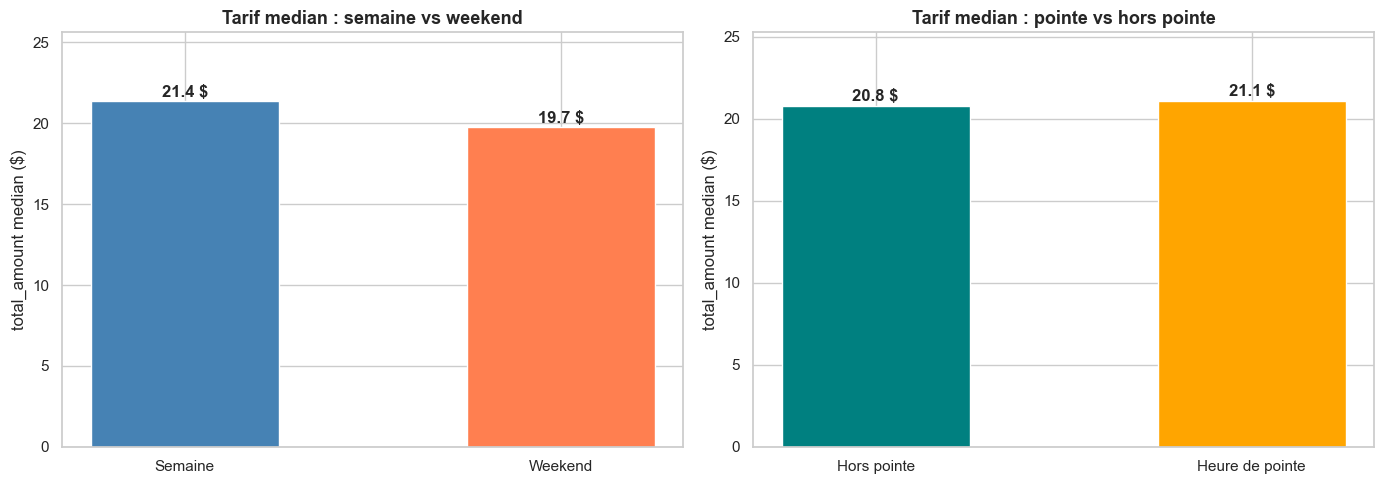

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tarif moyen : semaine vs weekend
labels_we = ['Semaine', 'Weekend']
moyennes_we = [
    df[df['est_weekend'] == 0]['total_amount'].median(),
    df[df['est_weekend'] == 1]['total_amount'].median()
]
axes[0].bar(labels_we, moyennes_we, color=['steelblue', 'coral'], edgecolor='white', width=0.5)
for i, v in enumerate(moyennes_we):
    axes[0].text(i, v + 0.3, f'{v:.1f} $', ha='center', fontweight='bold')
axes[0].set_title('Tarif median : semaine vs weekend', fontsize=13, fontweight='bold')
axes[0].set_ylabel('total_amount median ($)')
axes[0].set_ylim(0, max(moyennes_we) * 1.2)

# Tarif moyen : heure de pointe vs hors pointe
labels_hp = ['Hors pointe', 'Heure de pointe']
moyennes_hp = [
    df[df['est_heure_pointe'] == 0]['total_amount'].median(),
    df[df['est_heure_pointe'] == 1]['total_amount'].median()
]
axes[1].bar(labels_hp, moyennes_hp, color=['teal', 'orange'], edgecolor='white', width=0.5)
for i, v in enumerate(moyennes_hp):
    axes[1].text(i, v + 0.3, f'{v:.1f} $', ha='center', fontweight='bold')
axes[1].set_title('Tarif median : pointe vs hors pointe', fontsize=13, fontweight='bold')
axes[1].set_ylabel('total_amount median ($)')
axes[1].set_ylim(0, max(moyennes_hp) * 1.2)

plt.tight_layout()
plt.savefig('../figures/02_tarifs_periodes.png', dpi=150)
plt.show()

### Analyse des visualisations

**Durée des courses :**  
La majorité des trajets dure entre 5 et 20 minutes, cohérent avec les courtes distances observées dans le notebook 01. La distribution est asymétrique à droite — quelques courses longues (aéroports, embouteillages) allongent la moyenne.

**Vitesse moyenne :**  
La vitesse médiane tourne autour de 10-15 mph, reflet des conditions de circulation denses à Manhattan. On observe une vitesse plus élevée la nuit (3h-6h) quand le trafic est fluide, et plus basse aux heures de pointe — ce qui confirme la pertinence de la variable `est_heure_pointe`.

**Encodage cyclique :**  
Le graphique en cercle montre que les heures sont distribuées uniformément sur 360°. L'intérêt de cette représentation est qu'elle préserve la **continuité temporelle** : 23h et 0h sont proches sur le cercle, alors qu'une variable linéaire les traiterait comme opposées. Cela améliore les performances des modèles linéaires.

**Tarifs selon la période :**  
La comparaison semaine/weekend et pointe/hors-pointe permet de valider la pertinence de nos nouvelles features. Si les tarifs médians diffèrent entre les groupes, cela confirme que ces variables ont un pouvoir prédictif sur `total_amount`.

## 2.4 Récapitulatif des features créées

- **`duree_course`** : durée en minutes 
- **`heure_journee`** : heure de prise en charge (0-23) 
- **`jour_semaine`** : jour de la semaine (0=lundi, 6=dimanche)
- **`est_weekend`** : indicateur binaire weekend / semaine
- **`est_heure_pointe`** : indicateur binaire rush hours (7h-9h, 17h-19h)
- **`vitesse_moyenne`** : distance / durée en mph — état du trafic
- **`est_trajet_aeroport`** : indicateur binaire JFK/Newark (RatecodeID = 2 ou 3)
- **`heure_sin`** / **`heure_cos`** : encodage cyclique de l'heure pour les modèles linéaires

In [9]:
df.to_parquet('../data/yellow_tripdata_features.parquet', index=False)
print(f'Dataset avec features sauvegarde : {df.shape[0]:,} lignes, {df.shape[1]} colonnes')
print('Fichier : ../data/yellow_tripdata_features.parquet')

Dataset avec features sauvegarde : 64,452 lignes, 29 colonnes
Fichier : ../data/yellow_tripdata_features.parquet


## Conclusion

8 nouvelles variables ont été créées à partir des données brutes. Les variables temporelles
(`duree_course`, `est_heure_pointe`, encodage cyclique) et la `vitesse_moyenne` sont
particulièrement importantes pour les modèles de régression (notebook 03) et le clustering
(notebook 04).
